In [8]:
!tar -xvzf /content/dataset_animal/animalpose_keypoint_new/Self_collected_Images.tar.gz -C /content/dataset_animal/animalpose_keypoint_new/

animalpose_image_part2/
animalpose_image_part2/cat/
animalpose_image_part2/cat/ca1.jpeg
animalpose_image_part2/cat/ca10.jpeg
animalpose_image_part2/cat/ca100.jpeg
animalpose_image_part2/cat/ca101.jpeg
animalpose_image_part2/cat/ca102.jpeg
animalpose_image_part2/cat/ca103.jpeg
animalpose_image_part2/cat/ca104.jpeg
animalpose_image_part2/cat/ca105.jpeg
animalpose_image_part2/cat/ca106.jpeg
animalpose_image_part2/cat/ca107.jpeg
animalpose_image_part2/cat/ca108.jpeg
animalpose_image_part2/cat/ca109.jpeg
animalpose_image_part2/cat/ca11.jpeg
animalpose_image_part2/cat/ca110.jpeg
animalpose_image_part2/cat/ca111.jpeg
animalpose_image_part2/cat/ca112.jpeg
animalpose_image_part2/cat/ca113.jpeg
animalpose_image_part2/cat/ca114.jpeg
animalpose_image_part2/cat/ca115.jpeg
animalpose_image_part2/cat/ca116.jpeg
animalpose_image_part2/cat/ca117.jpeg
animalpose_image_part2/cat/ca118.jpeg
animalpose_image_part2/cat/ca119.jpeg
animalpose_image_part2/cat/ca12.jpeg
animalpose_image_part2/cat/ca120.jpeg
ani

Distribuição de animais no dataset: Counter({'dog': 1771, 'cat': 1466, 'sheep': 1078, 'horse': 960, 'cow': 842})
Quantidade de imagens de bovinos: 842


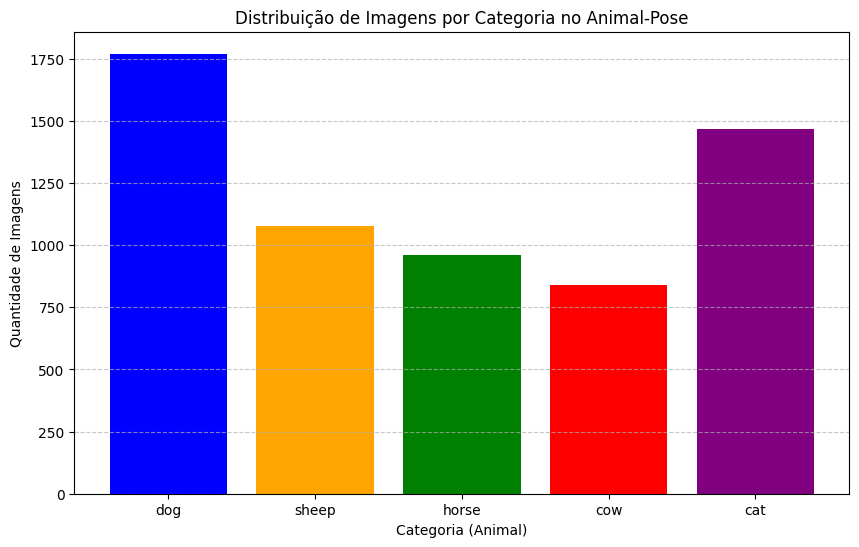

Total de bovinos no JSON inteiro: 842
Total de imagens de bovinos disponíveis na sua pasta: 200


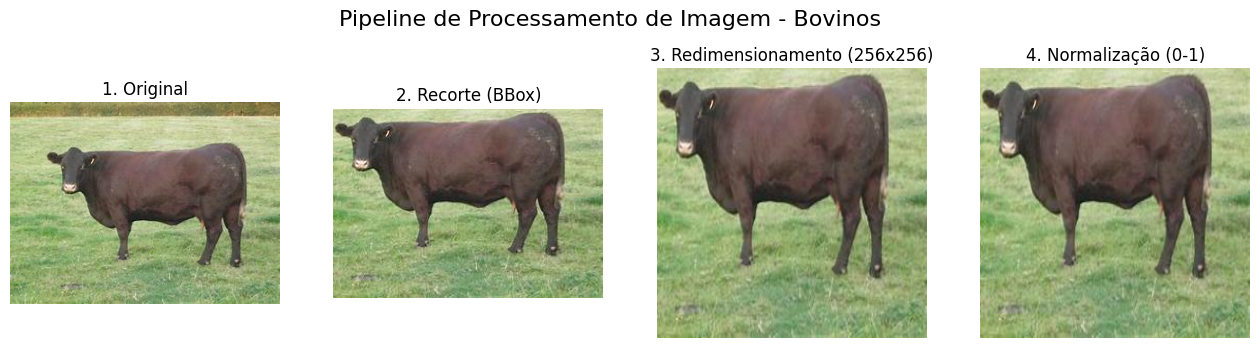

In [11]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

ANNOTATION_FILE = '/content/dataset_animal/animalpose_keypoint_new/keypoints.json'

IMAGE_DIR = '/content/dataset_animal/animalpose_keypoint_new/animalpose_image_part2/cow/'
with open(ANNOTATION_FILE, 'r') as f:
    annotations = json.load(f)

categorias = []
if 'categories' in annotations and 'annotations' in annotations:
    cat_dict = {cat['id']: cat['name'] for cat in annotations['categories']}
    for ann in annotations['annotations']:
        categorias.append(cat_dict[ann['category_id']])


contagem_animais = Counter(categorias)
print("Distribuição de animais no dataset:", contagem_animais)
qtd_bovinos = contagem_animais.get('cow', 0)
print(f"Quantidade de imagens de bovinos: {qtd_bovinos}")


plt.figure(figsize=(10, 6))
plt.bar(contagem_animais.keys(), contagem_animais.values(), color=['blue', 'orange', 'green', 'red', 'purple'])
plt.title('Distribuição de Imagens por Categoria no Animal-Pose')
plt.xlabel('Categoria (Animal)')
plt.ylabel('Quantidade de Imagens')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('eda_distribuicao.png')
plt.show()




cow_id = next((cat['id'] for cat in annotations['categories'] if cat['name'] == 'cow'), None)

todas_bovino_annotations = [ann for ann in annotations['annotations'] if ann['category_id'] == cow_id]

bovino_annotations = []
bovino_images = []

pasta_cow = '/content/dataset_animal/animalpose_keypoint_new/animalpose_image_part2/cow/'

for ann in todas_bovino_annotations:
    img_id = str(ann['image_id'])
    if img_id in annotations['images']:
        file_name = annotations['images'][img_id]
        nome_limpo = os.path.basename(file_name)
        img_path = os.path.join(pasta_cow, nome_limpo)

        if os.path.exists(img_path):
            bovino_images.append({'id': int(img_id), 'file_name': file_name})
            bovino_annotations.append(ann)

print(f"Total de bovinos no JSON inteiro: {len(todas_bovino_annotations)}")
print(f"Total de imagens de bovinos disponíveis na sua pasta: {len(bovino_annotations)}")

def processa_imagem(image_info, annotation_info, target_size=(256, 256)):
    nome_limpo = os.path.basename(image_info['file_name'])

    img_path = os.path.join('/content/dataset_animal/animalpose_keypoint_new/animalpose_image_part2/cow/', nome_limpo)

    img = cv2.imread(img_path)

    if img is None:
        raise ValueError(f"Não achei a imagem aqui: {img_path}. Verifique as pastas na esquerda!")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    bbox = annotation_info['bbox']
    x, y, w, h = map(int, bbox)
    img_cropped = img[y:y+h, x:x+w]

    img_resized = cv2.resize(img_cropped, target_size)
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img, img_cropped, img_resized, img_normalized


exemplo_img = bovino_images[0]
exemplo_ann = bovino_annotations[0]

img_original, img_crop, img_res, img_norm = processa_imagem(exemplo_img, exemplo_ann)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_original)
axes[0].set_title('1. Original')
axes[0].axis('off')

axes[1].imshow(img_crop)
axes[1].set_title('2. Recorte (BBox)')
axes[1].axis('off')

axes[2].imshow(img_res)
axes[2].set_title('3. Redimensionamento (256x256)')
axes[2].axis('off')

axes[3].imshow(img_norm)
axes[3].set_title('4. Normalização (0-1)')
axes[3].axis('off')

plt.suptitle('Pipeline de Processamento de Imagem - Bovinos', fontsize=16)
plt.savefig('pipeline_processamento.png')
plt.show()